# Task 1: Analyze monthly retention

 Task 1: Monthly retention analysis

- Define retention logic
- Build monthly cohorts
- Calculate retention rates
- Identify key patterns and best-performing cohorts

In [1]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

In [2]:
customers_data = pd.read_csv('olist_customers_dataset.csv')
orders_data = pd.read_csv('olist_orders_dataset.csv')
items_data = pd.read_csv('olist_order_items_dataset.csv')

In [3]:
orders_data

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [4]:
# Merge datasets into a single dataset using customer_id
customers_orders = pd.merge(customers_data, orders_data, on="customer_id")

In [5]:
customers_orders

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00


In [6]:
# Merge datasets into a single dataset using order_id
all_in = pd.merge(customers_orders, items_data, on="order_id")

In [7]:
all_in

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00,1,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88
112646,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00,1,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16
112647,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00,1,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04
112648,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00,1,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-09 21:15:51,689.00,22.07


In [8]:
# Inspect data types for all columns
all_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    112650 non-null  object 
 1   customer_unique_id             112650 non-null  object 
 2   customer_zip_code_prefix       112650 non-null  int64  
 3   customer_city                  112650 non-null  object 
 4   customer_state                 112650 non-null  object 
 5   order_id                       112650 non-null  object 
 6   order_status                   112650 non-null  object 
 7   order_purchase_timestamp       112650 non-null  object 
 8   order_approved_at              112635 non-null  object 
 9   order_delivered_carrier_date   111456 non-null  object 
 10  order_delivered_customer_date  110196 non-null  object 
 11  order_estimated_delivery_date  112650 non-null  object 
 12  order_item_id                 

In [9]:
# Convert required fields to datetime format
all_in['order_purchase_timestamp'] = pd.to_datetime(all_in['order_purchase_timestamp'])
all_in['order_approved_at'] = pd.to_datetime(all_in['order_approved_at'])
all_in['order_delivered_carrier_date'] = pd.to_datetime(all_in['order_delivered_carrier_date'])
all_in['order_delivered_customer_date'] = pd.to_datetime(all_in['order_delivered_customer_date'])
all_in['order_estimated_delivery_date'] = pd.to_datetime(all_in['order_estimated_delivery_date'])
all_in['shipping_limit_date'] = pd.to_datetime(all_in['shipping_limit_date'])

In [10]:
all_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    112650 non-null  object        
 1   customer_unique_id             112650 non-null  object        
 2   customer_zip_code_prefix       112650 non-null  int64         
 3   customer_city                  112650 non-null  object        
 4   customer_state                 112650 non-null  object        
 5   order_id                       112650 non-null  object        
 6   order_status                   112650 non-null  object        
 7   order_purchase_timestamp       112650 non-null  datetime64[ns]
 8   order_approved_at              112635 non-null  datetime64[ns]
 9   order_delivered_carrier_date   111456 non-null  datetime64[ns]
 10  order_delivered_customer_date  110196 non-null  datetime64[ns]
 11  

In [11]:
# Calculate the number of missing values per column
all_in.isna().sum()

customer_id                         0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
dtype: int64

In [12]:
# Make a copy of the original dataset to preserve the raw data
data_copy = all_in.copy()

In [13]:
# Extract month from the date
data_copy['order_period'] = data_copy['order_purchase_timestamp'].dt.to_period('M')

In [14]:
data_copy.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_period
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,2018-07


In [15]:
# Assign cohort groups based on the first activity date for each user
data_copy['cohort'] = data_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

In [16]:
data_copy.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_period,cohort
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,2017-05,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,2018-01,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,2018-05,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,2018-03,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,2018-07,2018-07


In [17]:
# Calculate the number of months since the user's first purchase (cohort age)
data_copy['month_diff'] = data_copy.order_period - data_copy.cohort
data_copy.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_period,cohort,month_diff
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,2017-06-05,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,2017-05,2017-05,<0 * MonthEnds>
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,2018-02-06,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,2018-01,2018-01,<0 * MonthEnds>
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,2018-06-13,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,2018-05,2018-05,<0 * MonthEnds>
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,2018-04-10,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,2018-03,2018-03,<0 * MonthEnds>
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,2018-08-15,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,2018-07,2018-07,<0 * MonthEnds>


In [18]:
# Compute the period index in days, approximating months by dividing by 30
data_copy['period_number_month'] = np.floor(data_copy.month_diff.apply(lambda x: x.n))

In [19]:
data_copy

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_period,cohort,month_diff,period_number_month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,2017-05,2017-05,<0 * MonthEnds>,0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,2018-01,2018-01,<0 * MonthEnds>,0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,2018-05,2018-05,<0 * MonthEnds>,0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,2018-03,2018-03,<0 * MonthEnds>,0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,2018-07,2018-07,<0 * MonthEnds>,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,...,1,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88,2018-04,2018-04,<0 * MonthEnds>,0
112646,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,...,1,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16,2018-04,2018-04,<0 * MonthEnds>,0
112647,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,...,1,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04,2018-04,2018-04,<0 * MonthEnds>,0
112648,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,...,1,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-09 21:15:51,689.00,22.07,2017-11,2017-11,<0 * MonthEnds>,0


In [20]:
# Group data by cohort and period index (in months) for aggregation
df_cohort = data_copy.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()
df_cohort

,cohort,period_number_month,n_customers
0,2016-09,0,3
1,2016-10,0,305
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
...,...,...,...
215,2018-06,2,16
216,2018-07,0,6054
217,2018-07,1,31
218,2018-08,0,6238


In [21]:
# Build a cohort pivot table for retention analysis
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')
cohort_pivot.head()

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,305.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,754.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1705.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [22]:
# Compute cohort sizes using the first column of the pivot table
cohort_size = cohort_pivot.iloc[:, 0]
cohort_size

cohort
2016-09       3.0
2016-10     305.0
2016-12       1.0
2017-01     754.0
2017-02    1705.0
2017-03    2595.0
2017-04    2339.0
2017-05    3560.0
2017-06    3114.0
2017-07    3843.0
2017-08    4149.0
2017-09    4090.0
2017-10    4412.0
2017-11    7217.0
2017-12    5442.0
2018-01    6983.0
2018-02    6422.0
2018-03    6947.0
2018-04    6709.0
2018-05    6604.0
2018-06    5934.0
2018-07    6054.0
2018-08    6238.0
Freq: M, Name: 0, dtype: float64

In [23]:
# Compute retention rates by normalizing values by cohort size
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [24]:
retention_matrix.head()

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003279,NaN,NaN,0.003279,NaN,0.003279,NaN,0.003279,NaN,0.003279,NaN,0.003279,0.006557,0.006557
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003979,0.002653,0.001326,0.003979,0.001326,0.003979,0.001326,0.001326,NaN,0.003979,0.001326,0.006631,0.003979,0.001326,0.001326,0.002653,0.003979,0.001326,NaN
2017-02,1.0,0.002346,0.002933,0.001173,0.004106,0.001173,0.002346,0.001760,0.001173,0.001760,0.001173,0.002933,0.001173,0.001760,0.001173,0.000587,0.000587,0.002346,NaN,NaN


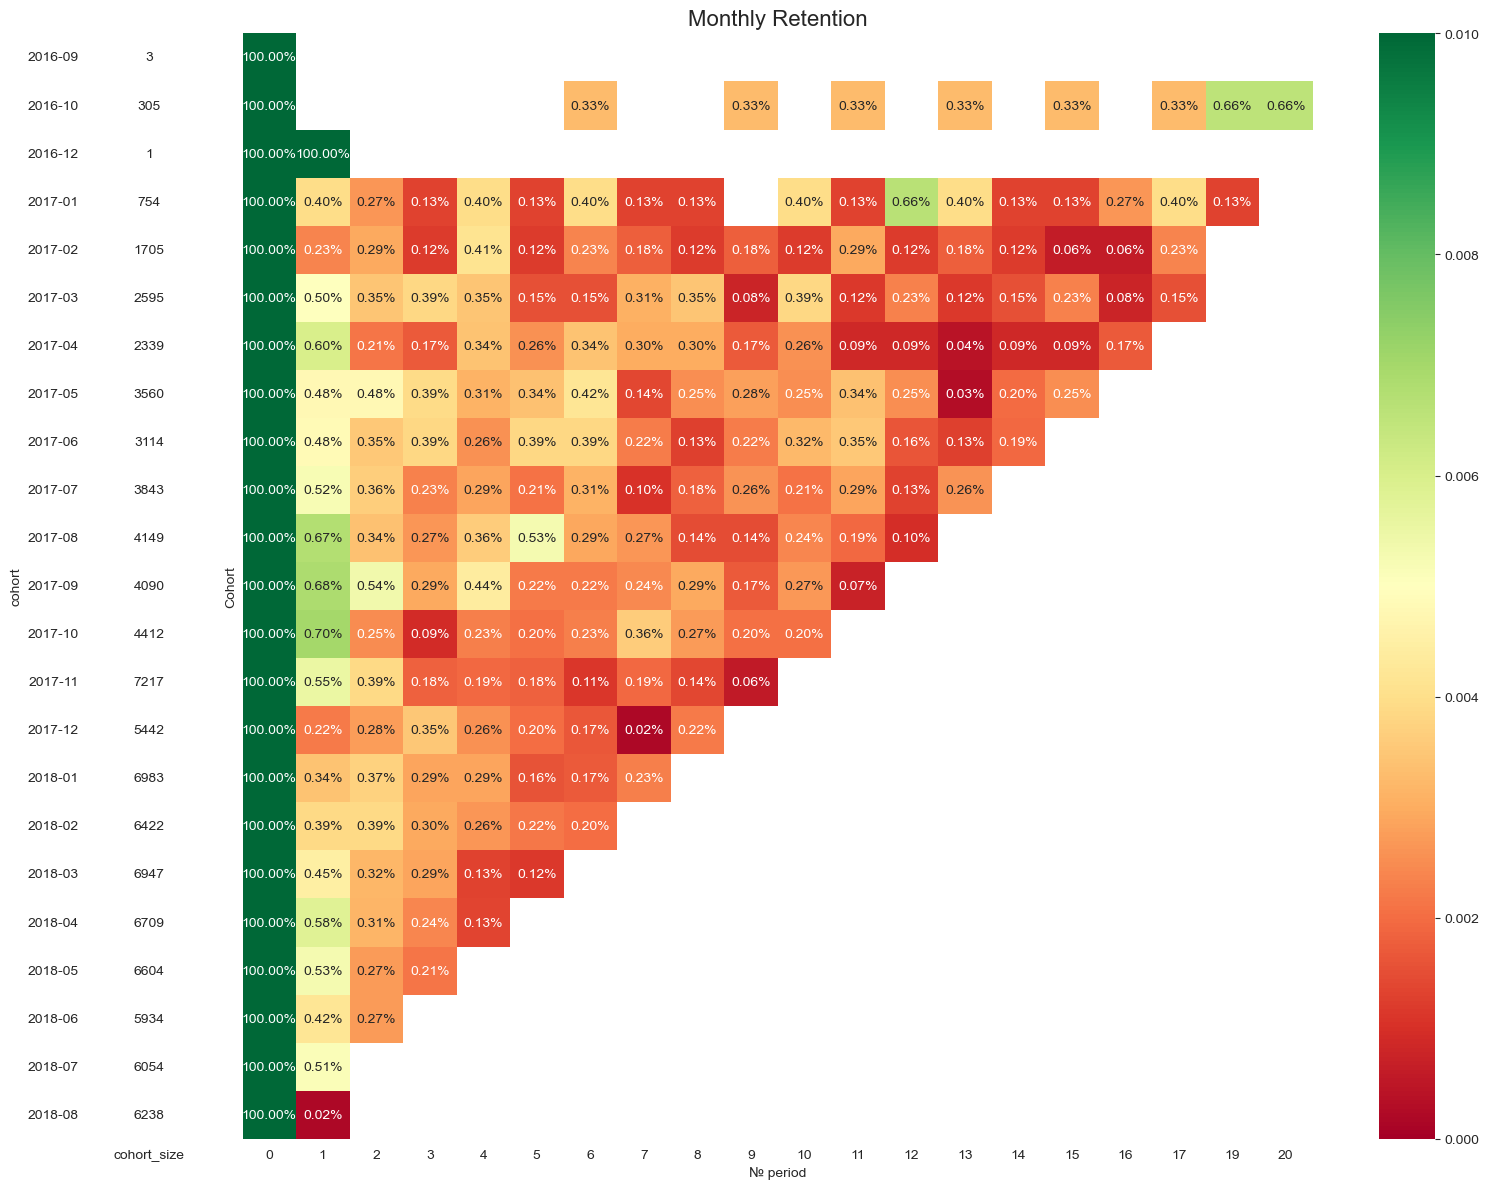

In [25]:
# Visualize cohort retention using a heatmap
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Retention rate heatmap
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1],
               vmin=0, vmax=0.01)
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ period', ylabel='Cohort')

    # Cohort size heatmap
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [26]:
# Calculate median month 1 retention across all cohorts
retention_matrix.describe()

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
count,23.0,21.000000,18.000000,17.000000,16.000000,15.000000,15.000000,13.000000,12.000000,11.000000,10.000000,10.000000,8.000000,8.000000,6.000000,6.000000,4.000000,4.000000,2.000000,1.000000
mean,1.0,0.052042,0.003353,0.002540,0.002902,0.002279,0.002641,0.002076,0.002107,0.001903,0.002653,0.002198,0.002171,0.001846,0.001465,0.001814,0.001430,0.002786,0.003942,0.006557
std,0.0,0.217211,0.000808,0.000947,0.000917,0.001126,0.000972,0.000939,0.000802,0.000821,0.000849,0.001114,0.001901,0.001333,0.000435,0.001055,0.000952,0.001066,0.003699,NaN
min,1.0,0.000160,0.002138,0.000907,0.001296,0.001152,0.001108,0.000184,0.001173,0.000554,0.001173,0.000733,0.000855,0.000281,0.000855,0.000587,0.000587,0.001541,0.001326,0.006557
25%,1.0,0.003979,0.002733,0.001801,0.002493,0.001558,0.001871,0.001404,0.001371,0.001578,0.002164,0.001199,0.001121,0.000974,0.001211,0.000973,0.000725,0.002145,0.002634,0.006557
50%,1.0,0.005010,0.003271,0.002651,0.002863,0.002040,0.002346,0.002248,0.002013,0.001760,0.002547,0.002395,0.001453,0.001522,0.001434,0.001819,0.001240,0.002812,0.003942,0.006557
75%,1.0,0.005813,0.003703,0.002959,0.003505,0.002383,0.003349,0.002651,0.002773,0.002425,0.003081,0.003192,0.002366,0.002771,0.001830,0.002474,0.001946,0.003454,0.005250,0.006557
max,1.0,1.000000,0.005379,0.003933,0.004401,0.005302,0.004213,0.003626,0.003468,0.003279,0.003979,0.003532,0.006631,0.003979,0.001966,0.003279,0.002653,0.003979,0.006557,0.006557


Median month 1 retention = 0.00501 (~0.5%), indicating very low repeat purchase rate

Let's ind the cohort with the highest retention rate in month 3:

The heatmap shows that the highest month 3 retention (~0.39%) is observed for the March, May, and June 2017 cohorts

In [27]:
# Analyze the distribution of users by number of orders
orders_per_user = data_copy.groupby('customer_unique_id')['order_id'].nunique()

orders_per_user.value_counts(normalize=True)

order_id
1     0.969472
2     0.028013
3     0.002012
4     0.000304
5     0.000094
6     0.000052
7     0.000031
9     0.000010
16    0.000010
Name: proportion, dtype: float64

- The heatmap shows that monthly retention for all cohorts rarely exceeds 1%. This low retention is driven by a high share of one-time buyers (~97%).

- To further analyze retention, a cohort of users with ≥2 purchases was examined. In this subset, a more expected retention pattern (diagonal structure) becomes visible.

- Overall, the majority of users do not make repeat purchases and do not stay on the platform.Further analysis focuses on users with 2+ orders.

In [28]:
# Filter users with >= 2 purchases
users_2p = orders_per_user[orders_per_user >= 2].index
data_2p = data_copy[data_copy.customer_unique_id.isin(users_2p)].copy()

# Define cohort as the month of first purchase
data_2p['cohort'] = (data_2p.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
)

# Month of the event
data_2p['order_month'] = data_2p['order_purchase_timestamp'].dt.to_period('M')

# Period number
data_2p['period_number'] = (
    data_2p['order_month'] - data_2p['cohort']
).apply(attrgetter('n'))

# Aggregate data
df_cohort_2p = (
    data_2p
    .groupby(['cohort', 'period_number'])
    .agg(n_customers=('customer_unique_id', 'nunique'))
    .reset_index()
)

# Create a pivot table
cohort_pivot_2p = df_cohort_2p.pivot_table(
    index='cohort',
    columns='period_number',
    values='n_customers'
)

# Retention
retention_2p = cohort_pivot_2p.divide(cohort_pivot_2p[0], axis=0)


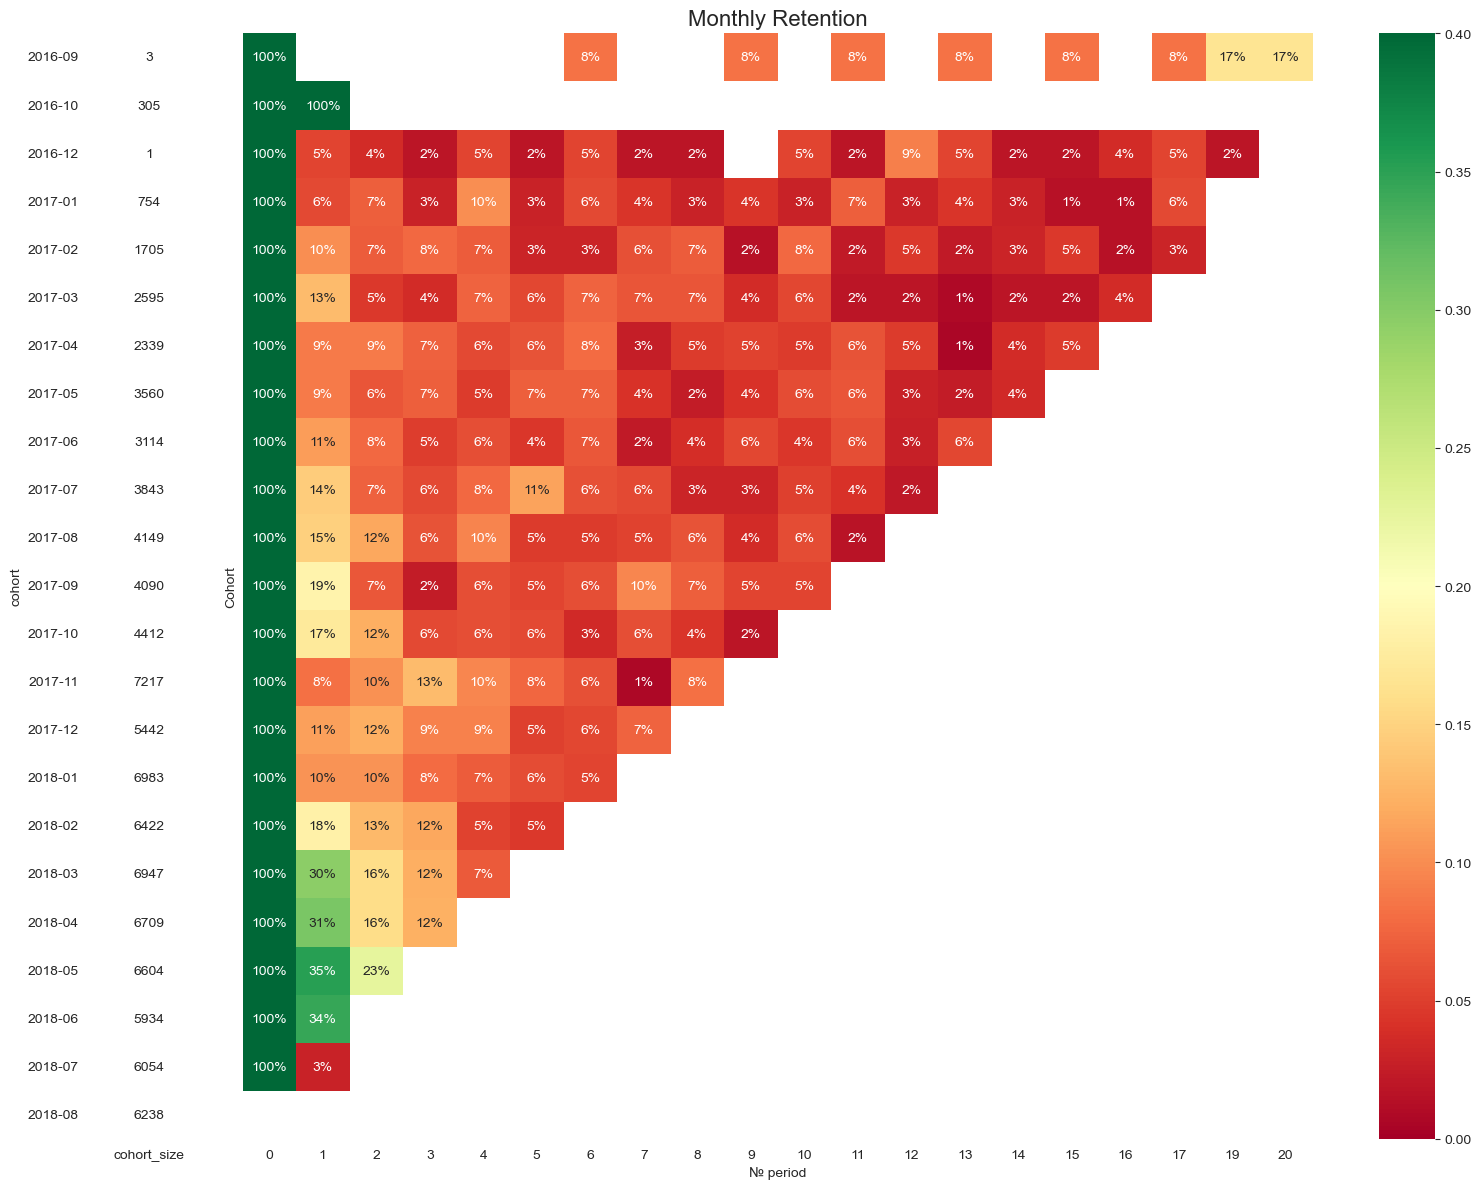

In [29]:
# Visualize cohort retention using a heatmap
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Heatmap of retention rates
    sns.heatmap(retention_2p,
                mask=retention_2p.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1],
               vmin=0, vmax=0.4)
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ period', ylabel='Cohort')

    # Cohort size heatmap
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

- The chart shows that retention for order completion remains low, even among users with at least two purchases.

- A slight increase is observed between July–October 2017 and March–June 2018, which may be influenced by external factors or marketing activity.

- The September 2019 cohort shows higher retention, but its small size makes it unreliable for separate analysis.

- By month 5, retention drops to ~5–6% across most cohorts(with minor exceptions such as July and November 2017).

In [30]:
# Let's calculate median month 1 retention across all cohorts
retention_2p.describe()

period_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
count,22.0,21.000000,18.000000,17.000000,16.000000,15.000000,15.000000,13.000000,12.000000,11.000000,10.000000,10.000000,8.000000,8.000000,6.000000,6.000000,4.000000,4.000000,2.000000,1.000000
mean,1.0,0.194682,0.101609,0.071667,0.071095,0.054252,0.059425,0.048094,0.048585,0.042457,0.053049,0.046031,0.038682,0.037169,0.028066,0.038021,0.025884,0.056507,0.092424,0.166667
std,0.0,0.207422,0.046617,0.035585,0.016920,0.022386,0.014617,0.025074,0.021359,0.019004,0.012408,0.025515,0.023593,0.026635,0.008005,0.026603,0.012706,0.021402,0.104995,NaN
min,1.0,0.028571,0.036364,0.018182,0.047059,0.018182,0.031008,0.006849,0.018182,0.015504,0.028571,0.015873,0.018692,0.005236,0.018182,0.014286,0.014286,0.031008,0.018182,0.166667
25%,1.0,0.089005,0.070183,0.049724,0.059308,0.045491,0.054132,0.026178,0.030339,0.033982,0.048227,0.019833,0.025873,0.019778,0.021162,0.018309,0.015199,0.048661,0.055303,0.166667
50%,1.0,0.130841,0.095872,0.070588,0.068975,0.053892,0.059880,0.052910,0.045205,0.041176,0.054219,0.051005,0.028992,0.033193,0.029790,0.032602,0.025934,0.055844,0.092424,0.166667
75%,1.0,0.185629,0.121142,0.093023,0.081246,0.060339,0.068443,0.062016,0.066507,0.053124,0.057669,0.064236,0.046664,0.054721,0.034223,0.046968,0.036619,0.063690,0.129545,0.166667
max,1.0,1.000000,0.225352,0.130137,0.100000,0.113402,0.083333,0.095808,0.082192,0.083333,0.077519,0.083333,0.090909,0.083333,0.036649,0.083333,0.037383,0.083333,0.166667,0.166667


Median month 1 retention = 0.130841 (~13.1%), indicating moderate repeat purchase behavior among this segment

Let's identify the cohort with the highest retention rate in month 3:

Based on the heatmap, the November 2017 cohort has the highest
month 3 retention (~13%).

# Task 2: Assess whether the marketplace has achieved product–market fit

1. Assess product–market fit based on the cohort analysis results obtained in the previous step: 

Retention serves as a proxy for product–market fit, indicating very low PMF. Most users do not return after their first purchase, and even among repeat users, retention averages only ~6–7%.

2. Define short-term priorities for the marketplace:

 In the short term, the marketplace should primarily focus on churn.

It is important to understand:
- why users do not return after their first purchase  
- what friction points or negative experiences occur along the user journey  
- what differentiates users who make repeat purchases  

Special attention should be given to identifying at which stage users drop off and what may discourage them from making another order.

Since retention drops significantly after the first purchase, the key focus should be on improving **month 1 retention**.

# Task 3: Define five key metrics to focus on

## Key Product Metrics

- Revenue  
- Active users completing the key action (delivered orders)  
- User engagement (favorites, shares, product interactions)  
- Retention rate  
- ARPPU (Average Revenue Per Paying User)

In [31]:
all_in['order_period'] = all_in['order_purchase_timestamp'].dt.to_period('M')

In [32]:
# Plot revenue
total_rev = all_in.copy()
total_rev = total_rev.query('order_status == "delivered"').groupby('order_period', as_index=False).agg({'price':'sum'})
total_rev

,order_period,price
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


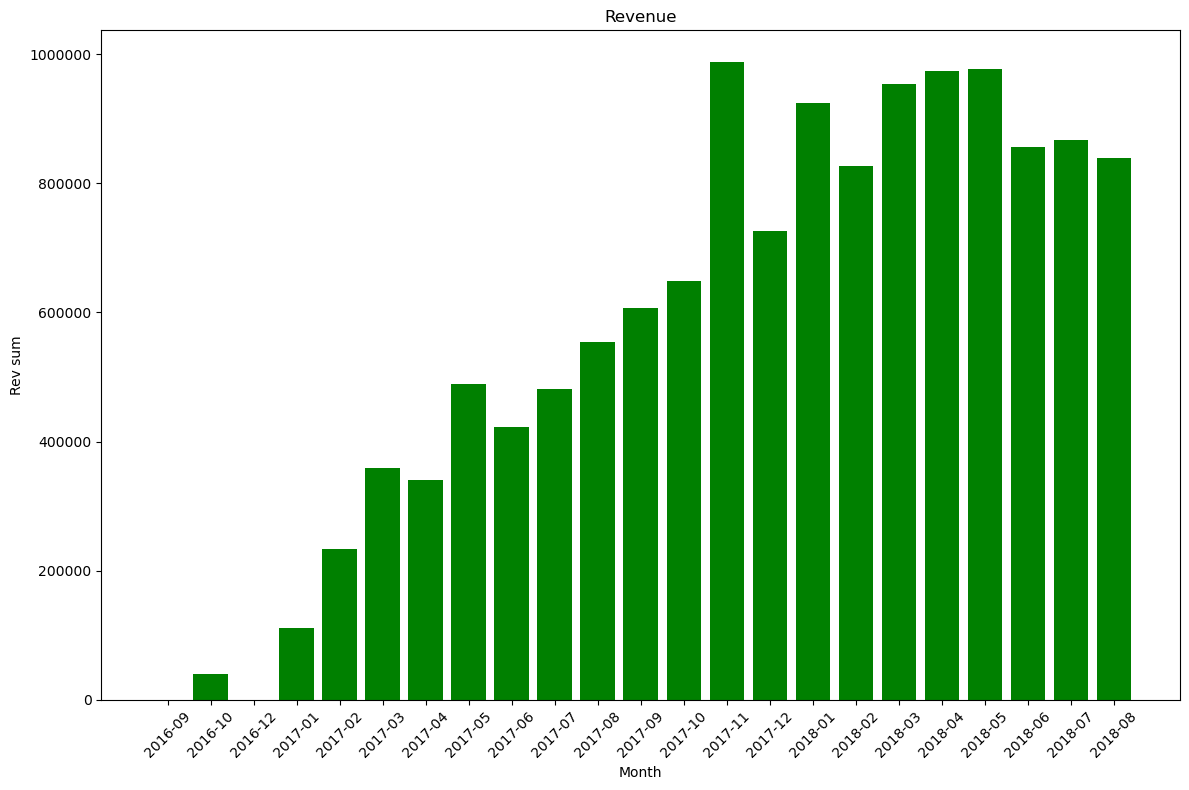

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))
x_values = total_rev['order_period'].astype(str)
plt.bar(x_values, total_rev['price'], color='green')
ax.ticklabel_format(axis='y', style='plain')

plt.title("Revenue")
plt.xlabel("Month")
plt.ylabel("Rev sum")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Plot active users
active_users = all_in.copy()
active_users = active_users.query('order_status == "delivered"').groupby('order_period', as_index=False).agg({'customer_unique_id':'nunique'})
active_users

,order_period,customer_unique_id
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,718
4,2017-02,1630
5,2017-03,2508
6,2017-04,2274
7,2017-05,3479
8,2017-06,3076
9,2017-07,3802


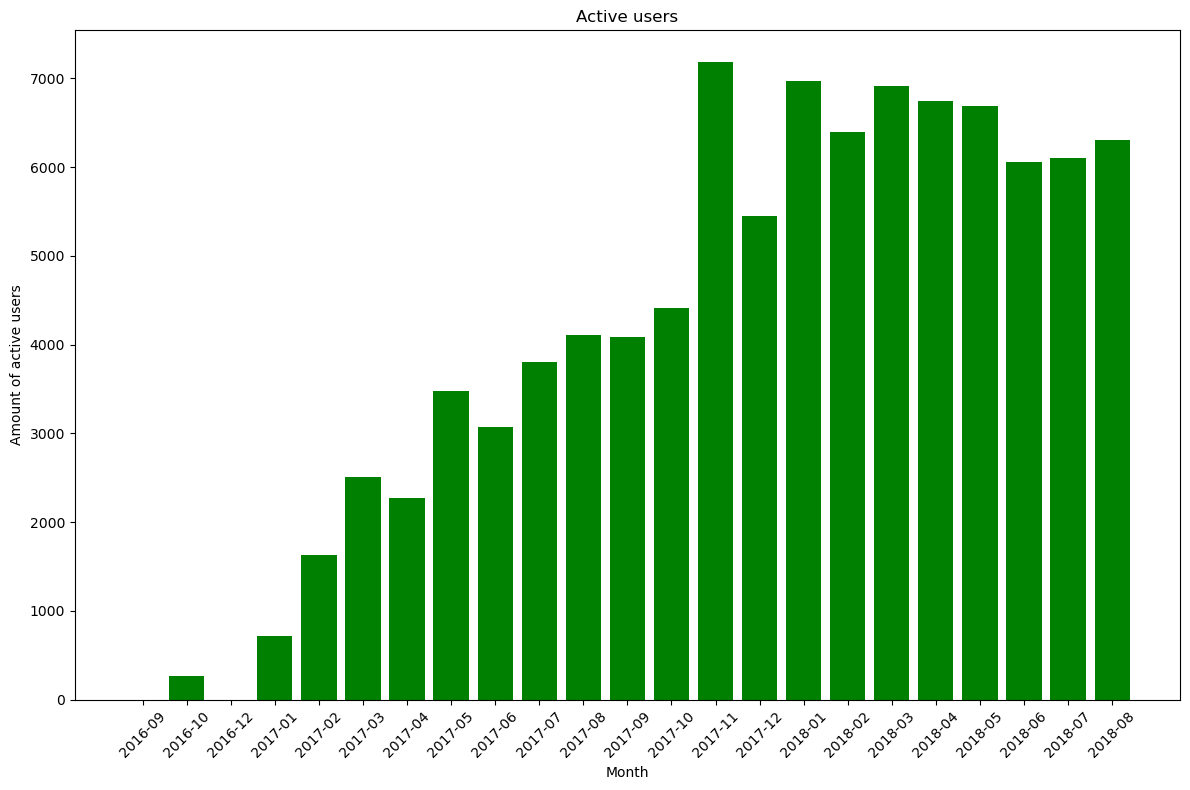

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))
x_values = total_rev['order_period'].astype(str)
plt.bar(x_values, active_users['customer_unique_id'], color='green')
ax.ticklabel_format(axis='y', style='plain')

plt.title("Active users")
plt.xlabel("Month")
plt.ylabel("Аmount of active users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

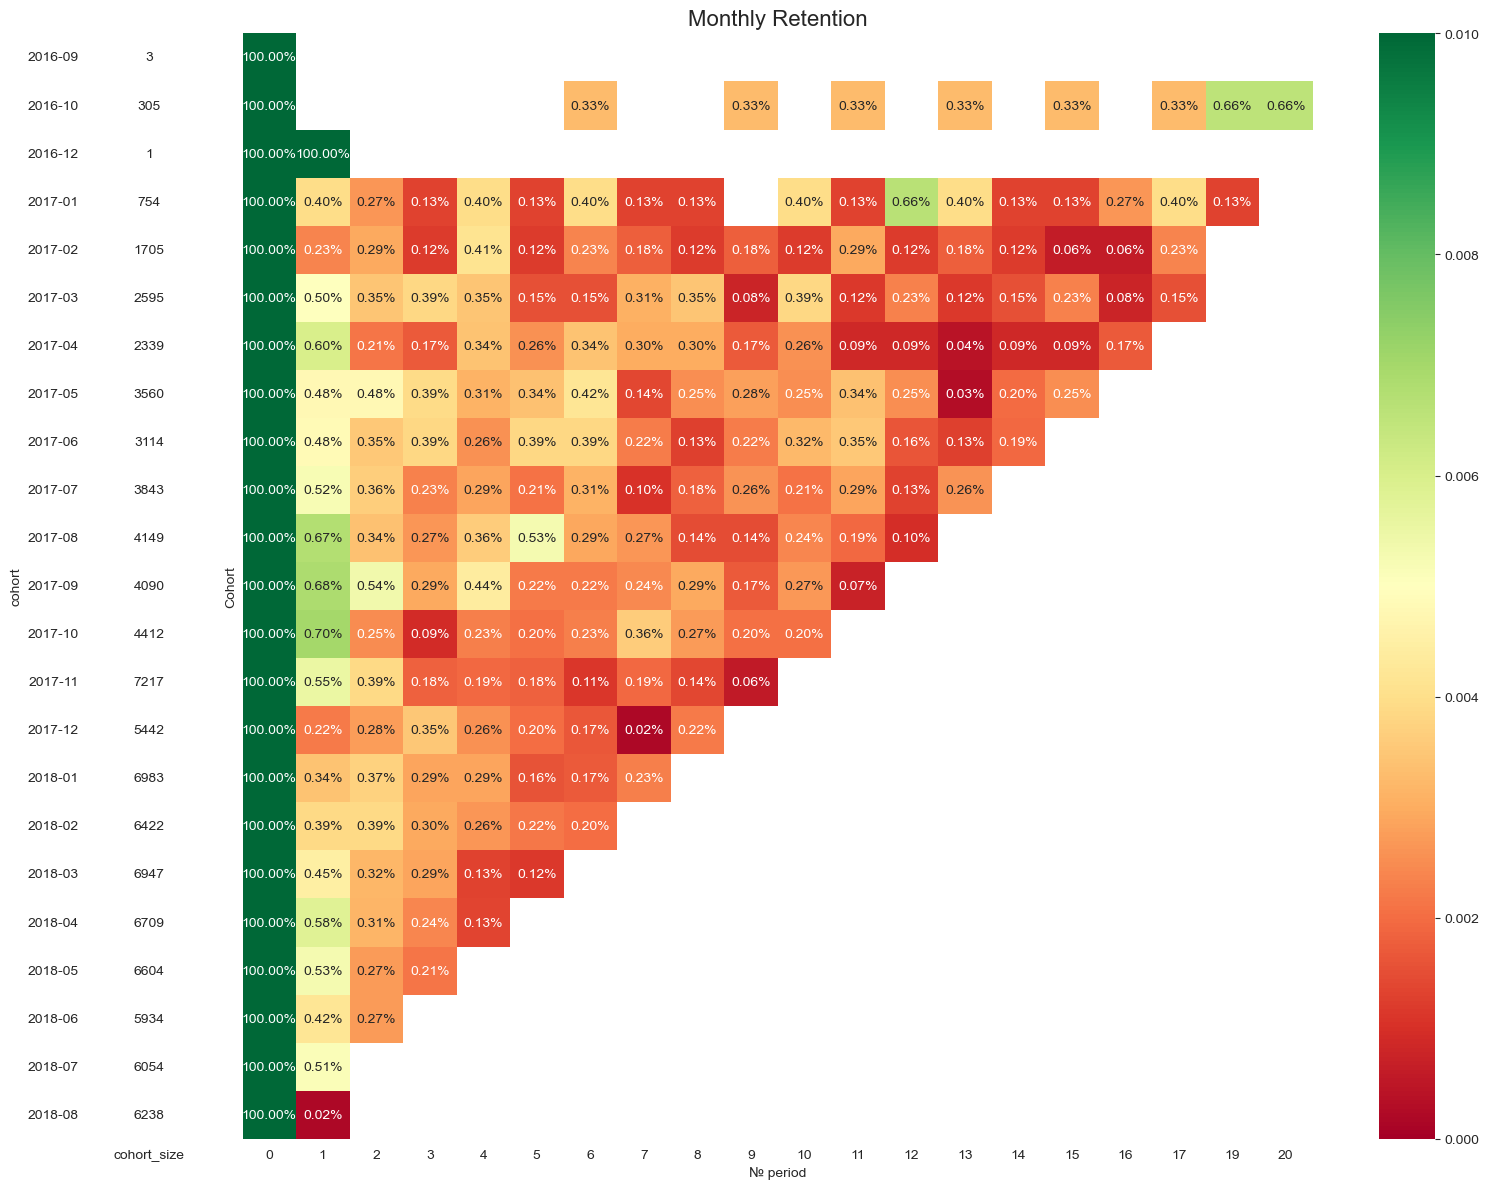

In [36]:
# Retention analysis and visualization were performed earlier

with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                cmap='RdYlGn',
                ax=ax[1],
               vmin=0, vmax=0.01)
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ period', ylabel='Cohort')

    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [37]:
# Plot ARPPU
ARPPU = all_in.copy()

In [38]:
ARPPU = ARPPU.query('order_status == "delivered"').groupby('order_period', as_index=False).agg(total_rev=('price','sum'), n_cust=('customer_unique_id','nunique'))

In [39]:
ARPPU['arppu'] = ARPPU.total_rev / ARPPU.n_cust
ARPPU

,order_period,total_rev,n_cust,arppu
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,262,153.912634
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,718,155.708022
4,2017-02,234223.40,1630,143.695337
5,2017-03,359198.85,2508,143.221232
6,2017-04,340669.68,2274,149.810765
7,2017-05,489338.25,3479,140.654858
8,2017-06,421923.37,3076,137.166245
9,2017-07,481604.52,3802,126.671362


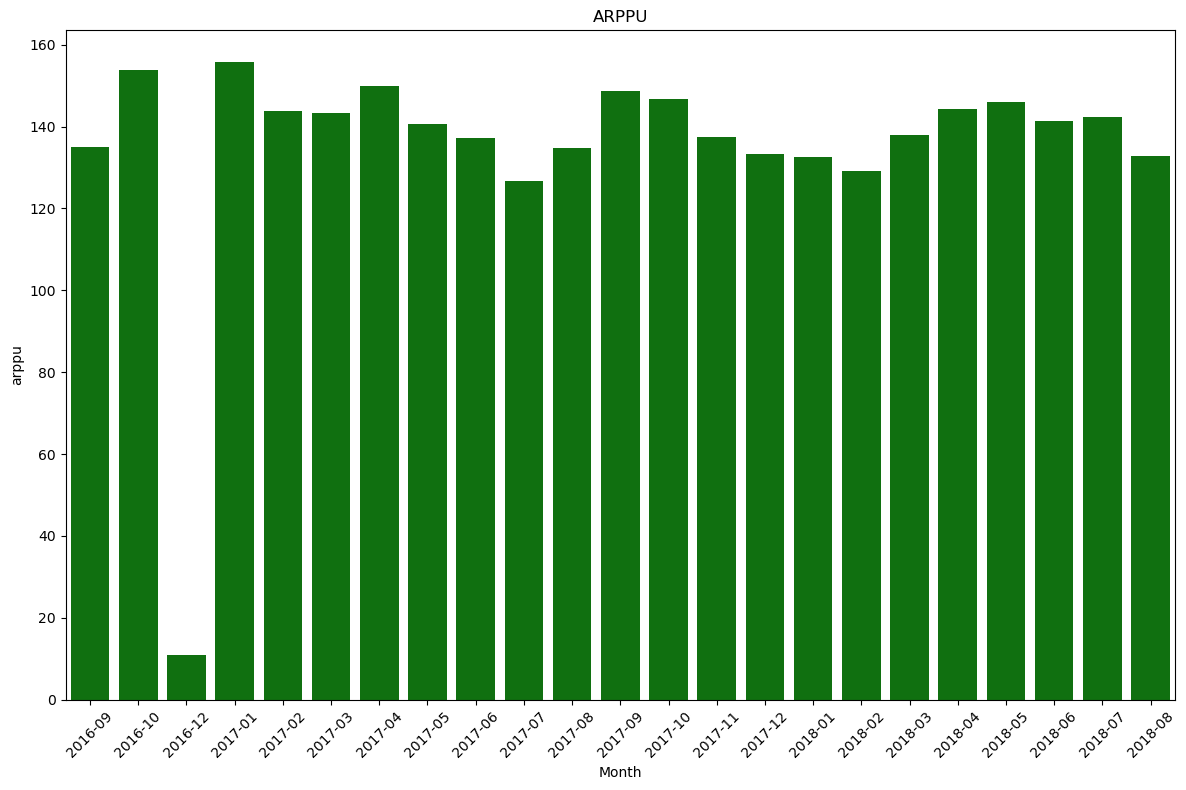

In [40]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=ARPPU, x='order_period', y='arppu', color='green')

plt.title("ARPPU")
plt.xlabel("Month")
plt.ylabel("arppu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task 4: Prioritize one of the top 3 hypotheses using the ICE framework

In [41]:
Impact_scale_data = {
    'Impact': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Metric value': ['0 - 50', '51 - 150', '151 - 350', '351 - 750', '751 - 1550', 
                        '1551 - 3150', '3151 - 6350', '6351 - 12750', '12751 - 25550', 
                        '25551 - 51150']
}

Impact_scale = pd.DataFrame(Impact_scale_data)

Impact_scale

,Impact,Metric value
0,1,0 - 50
1,2,51 - 150
2,3,151 - 350
3,4,351 - 750
4,5,751 - 1550
5,6,1551 - 3150
6,7,3151 - 6350
7,8,6351 - 12750
8,9,12751 - 25550
9,10,25551 - 51150


In [42]:
# For Impact calculation, use data starting from June 2017. Assume that repeat purchase conversion equals the median month 1 retention.
# Repeat purchase conversion = 0.00501
CR = 0.005010

Fixing the order processing issue is expected to eliminate cancellations, resulting in a higher number of successfully delivered orders.

In [43]:
cancelation = all_in.query('order_status == "canceled" and order_period > "2017-07"').agg({'price':'sum'})
IM1 = cancelation*CR
IM1
# impact = 3

price    329.454995
dtype: float64

Reducing time to shipment is expected to improve user experience, leading to higher repeat purchase rates and increased order volume

In [44]:
time_of_shipment = all_in.query('order_delivered_customer_date > order_estimated_delivery_date and order_period > "2017-07"').agg({'price':'sum'})
IM2 = time_of_shipment*CR
IM2
# impact = 7

price    5128.381591
dtype: float64

A new payment method is expected to reduce checkout friction, improving repeat purchase conversion and increasing overall order volume

In [45]:
mn = all_in.copy()
mn['diff'] = (mn.order_approved_at - mn.order_purchase_timestamp).dt.days
mn.sort_values('diff', ascending=False)
bb = mn.groupby('diff', as_index=False).agg({'customer_id':'count'})
bb

,diff,customer_id
0,0.0,92395
1,1.0,14325
2,2.0,3332
3,3.0,1704
4,4.0,469
5,5.0,286
6,6.0,36
7,7.0,19
8,8.0,13
9,9.0,3


In [46]:
# Filter users with payment processing time greater than 1 day
payment_type = mn.query('order_status == "invoiced" and order_period > "2017-07" and diff > 0').agg({'price':'sum'})
IM3 = payment_type*CR
IM3
# impact = 1

price    36.238432
dtype: float64

In [47]:
data = [
    {'Hypothesis': 'Fixing issues in the order processing system', 'Impact': 3, 'Confidence': 8, 'Ease': 6},
    {'Hypothesis': 'Reducing time to shipment', 'Impact': 7, 'Confidence': 10, 'Ease': 4},
    {'Hypothesis': 'Introducing a new payment method', 'Impact': 1, 'Confidence': 5, 'Ease': 9}
]

df = pd.DataFrame(data)
df['ICE'] = df.Impact * df.Confidence * df.Ease
df

,Hypothesis,Impact,Confidence,Ease,ICE
0,Fixing issues in the order processing system,3,8,6,144
1,Reducing time to shipment,7,10,4,280
2,Introducing a new payment method,1,5,9,45


Conclusion: According to the ICE prioritization, the hypothesis of reducing time to shipment is selected as the most promising, having the highest overall score

# Task 5: Identify key metrics influenced by the selected hypothesis

## Hypothesis: Reducing time to shipment is expected to improve retention by increasing repeat purchases

Target metric:
- Month 1 retention rate

Proxy metric:
- Time from purchase to shipment

Guardrail metric:
- Order cancellation rate

# Task 6: Formulate conclusions and deliver a final report

### Problem Definition
Cohort analysis and order frequency distribution reveal low retention starting from month 1, with only ~3% of users making a repeat purchase.

---

### Key Findings

- Low retention indicates that the product does not fully meet market needs  
- The primary issue lies in **high churn after the first purchase**  
- It is critical to understand:
  - why users do not return  
  - where friction occurs in the user journey  
  - what differentiates repeat buyers  

---

### Focus Metrics

To improve performance, the product should focus on:

- Revenue  
- Number of users completing the key action (delivered orders)  
- User engagement (favorites, shares, product interactions)  
- Retention rate  
- ARPPU (Average Revenue Per Paying User)  

---

### Hypothesis Selection

Three hypotheses were generated and evaluated using the ICE framework.

The selected hypothesis:
👉 **Reducing time to shipment**

Expected impact:
- Improve retention  
- Reduce time from purchase to shipment  

Important guardrail:
- Monitor cancellation rate to ensure that faster processing does not increase errors  

---

### Product Recommendations

- Reduce shipment time  
- Identify and fix issues in the order processing system  
- Re-run cohort analysis after implementing changes to measure retention improvements  